In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [33]:
# Подключаем Google Диск к Colab
from google.colab import drive
drive.mount('/content/drive')

attendance_enriched = pd.read_csv('/content/drive/MyDrive/проект аналитика/attendance_enriched_new.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# 1. Анализ всех групп в ИТИАД
print("="*60)
print("АНАЛИЗ ГРУПП ИТИАД")
print("="*60)

# Фильтруем только ИТИАД
itiad_df = attendance_enriched[attendance_enriched['Faculty'] == 'Институт информационных технологий и анализа данных'].copy()

# Извлекаем базовые названия групп
itiad_df['Group_Base'] = itiad_df['Group'].str.extract(r'([A-Za-zА-Яа-я]+)')[0]

# Анализируем все группы в ИТИАД
group_stats = itiad_df.groupby('Group_Base').agg({
    'mira_id': 'nunique',
    'id': 'count'
}).rename(columns={'mira_id': 'unique_students', 'id': 'total_records'}).sort_values('unique_students', ascending=False)

print("\nВсе группы ИТИАД с количеством студентов:")
print(group_stats)
print(f"\nВсего различных групп: {len(group_stats)}")

# 2. Выбираем группу для анализа
TARGET_GROUP = 'АСУб'

print(f"\n" + "="*60)
print(f"АНАЛИЗ ГРУППЫ: {TARGET_GROUP}")
print("="*60)

# 3. Фильтруем данные по выбранной группе
group_df = itiad_df[itiad_df['Group_Base'] == TARGET_GROUP].copy()

# Статистика по группе
print(f"\nСтатистика по группе {TARGET_GROUP}:")
print(f"- Всего записей: {len(group_df)}")
print(f"- Уникальных студентов: {group_df['mira_id'].nunique()}")
print(f"- Варианты названий групп: {group_df['Group'].unique()}")
print(f"- Года групп: {sorted(group_df['Group'].str.extract(r'(\d+)')[0].dropna().unique())}")

# Проверяем, что студентов достаточно для обучения
if group_df['mira_id'].nunique() < 10:
    print(f"\nВНИМАНИЕ: Группа {TARGET_GROUP} содержит мало студентов ({group_df['mira_id'].nunique()})")
    print("Рекомендуется выбрать другую группу с большим количеством студентов")


АНАЛИЗ ГРУПП ИТИАД

Все группы ИТИАД с количеством студентов:
            unique_students  total_records
Group_Base                                
ИСТб                    154          45652
АСУб                    132          31963
ИБб                     104          22844
ЭВМб                     87          18167
ИСИб                     64          10736
КСм                      24           1414
ИИТм                     22           1455
ИТПм                     17            619
БКСм                     15           1287
ЦППм                      7            326

Всего различных групп: 10

АНАЛИЗ ГРУППЫ: АСУб

Статистика по группе АСУб:
- Всего записей: 31963
- Уникальных студентов: 132
- Варианты названий групп: ['АСУб-21' 'АСУб-22' 'АСУб-24' 'АСУб-23']
- Года групп: ['21', '22', '23', '24']


In [35]:
# ============================================================
# ОБУЧЕНИЕ МОДЕЛИ ДЛЯ ВЫБРАННОЙ ГРУППЫ
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Функция для нормализации оценок
def normalize_grade(grade):
    if pd.isna(grade):
        return np.nan
    if isinstance(grade, str):
        grade_lower = grade
        if 'Зачтено' in grade_lower and 'Не зачтено' not in grade_lower:
            return 5.0
        elif 'Не зачтено' in grade_lower or 'Н/Я' in grade_lower:
            return 2.0
        else:
            try:
                clean_grade = ''.join(c for c in grade if c.isdigit() or c == '.' or c == ',')
                clean_grade = clean_grade.replace(',', '.')
                return float(clean_grade)
            except:
                return np.nan
    else:
        try:
            return float(grade)
        except:
            return np.nan

# Добавляем числовой столбец с оценкой
group_df['grade_numeric'] = group_df['Result'].apply(normalize_grade)

# Удаляем строки с некорректными оценками
print(f"\nИсходное количество записей: {len(group_df)}")
group_df = group_df.dropna(subset=['grade_numeric'])
print(f"После удаления некорректных оценок: {len(group_df)}")

# Определяем курс студента по группе
def group_to_course(group_name):
    """Определяет курс по названию группы"""
    # Извлекаем год из названия группы
    year_match = re.search(r'(\d+)', str(group_name))
    if year_match:
        year = int(year_match.group(1))
        # Предполагаем, что 24 год - 1 курс, 23 - 2 курс, 22 - 3 курс, 21 - 4 курс
        if year >= 24:
            return 1
        elif year == 23:
            return 2
        elif year == 22:
            return 3
        elif year == 21:
            return 4
    return None

group_df['student_course'] = group_df['Group'].apply(group_to_course)

# Создаем признаки для каждого студента
print("\nСоздаем расширенные признаки для студентов...")

student_features = []

for mira_id in group_df['mira_id'].unique():
    student_data = group_df[group_df['mira_id'] == mira_id]

    # Определяем курс (берем первый попавшийся, предполагаем, что у студента он один)
    student_course = student_data['student_course'].iloc[0] if not student_data['student_course'].isna().all() else None

    # Базовые признаки
    grades = student_data['grade_numeric'].values

    avg_grade = np.mean(grades)
    std_grade = np.std(grades) if len(grades) > 1 else 0
    min_grade = np.min(grades)
    max_grade = np.max(grades)
    num_subjects = len(grades)

    # Процент оценок в разных диапазонах
    excellent = np.sum(grades >= 4.5) / num_subjects if num_subjects > 0 else 0
    good = np.sum((grades >= 4.0) & (grades < 4.5)) / num_subjects if num_subjects > 0 else 0
    satisfactory = np.sum((grades >= 3.0) & (grades < 4.0)) / num_subjects if num_subjects > 0 else 0
    poor = np.sum(grades < 3.0) / num_subjects if num_subjects > 0 else 0

    # Количество различных оценок
    unique_grades = len(np.unique(grades))

    student_features.append({
        'mira_id': mira_id,
        'student_course': student_course,
        'avg_grade': avg_grade,
        'std_grade': std_grade,
        'min_grade': min_grade,
        'max_grade': max_grade,
        'num_subjects': num_subjects,
        'excellent_rate': excellent,
        'good_rate': good,
        'satisfactory_rate': satisfactory,
        'poor_rate': poor,
        'unique_grades': unique_grades,
        'group': student_data['Group'].iloc[0]
    })

# Создаем DataFrame с признаками
features_df = pd.DataFrame(student_features)

print(f"Создано {len(features_df)} записей с признаками")




Исходное количество записей: 31963
После удаления некорректных оценок: 31963

Создаем расширенные признаки для студентов...
Создано 132 записей с признаками


In [36]:
# ============================================================
# ДОБАВЛЕНИЕ ПРИЗНАКОВ ПОСЕЩАЕМОСТИ
# ============================================================

print("\nДобавляем признаки посещаемости...")

# Берём уникальные пары студент-предмет
unique_attendance = group_df[['mira_id', 'всего_занятий', 'посещений', 'процент_посещений']].drop_duplicates()

# Агрегируем по студентам
attendance_features = unique_attendance.groupby('mira_id').agg(
    total_lessons_all=('всего_занятий', 'sum'),
    total_attended_all=('посещений', 'sum'),
    avg_subject_attendance=('процент_посещений', 'mean'),
    std_subject_attendance=('процент_посещений', 'std'),
    min_subject_attendance=('процент_посещений', 'min'),
    max_subject_attendance=('процент_посещений', 'max'),
    num_subjects_with_attendance=('всего_занятий', 'count')
).reset_index()

# Общий процент посещаемости
attendance_features['overall_attendance_percent'] = (
    attendance_features['total_attended_all'] / attendance_features['total_lessons_all'] * 100
).round(1)

attendance_features.fillna(0, inplace=True)

# Объединяем с features_df
features_df = features_df.merge(attendance_features, on='mira_id', how='left')

# Заполняем нулями студентов без данных посещаемости
attendance_cols = [
    'total_lessons_all', 'total_attended_all', 'avg_subject_attendance',
    'std_subject_attendance', 'min_subject_attendance', 'max_subject_attendance',
    'num_subjects_with_attendance', 'overall_attendance_percent'
]
features_df[attendance_cols] = features_df[attendance_cols].fillna(0)

print("Признаки посещаемости добавлены.")
print(features_df.head())




Добавляем признаки посещаемости...
Признаки посещаемости добавлены.
     mira_id  student_course  avg_grade  std_grade  min_grade  max_grade  \
0  2418744.0               4   3.464286   1.295105        2.0        5.0   
1  2425907.0               4   3.158730   1.382502        2.0        5.0   
2  2421197.0               3   4.317073   0.829507        3.0        5.0   
3  2445089.0               3   4.609971   0.854737        2.0        5.0   
4  2441444.0               3   4.831776   0.374065        4.0        5.0   

   num_subjects  excellent_rate  good_rate  satisfactory_rate  ...  \
0            28        0.392857   0.000000           0.285714  ...   
1            63        0.317460   0.095238           0.015873  ...   
2           123        0.552846   0.211382           0.235772  ...   
3           341        0.774194   0.143695           0.000000  ...   
4           321        0.831776   0.168224           0.000000  ...   

   unique_grades    group total_lessons_all  total_at

In [37]:
# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
# ============================================================

print("\nПодготовка данных для модели предсказания...")

# Разделяем студентов по курсам
course1 = features_df[features_df['student_course'] == 1]
course2 = features_df[features_df['student_course'] == 2]
course3 = features_df[features_df['student_course'] == 3]
course4 = features_df[features_df['student_course'] == 4]

print(f"Студентов 1 курса: {len(course1)}")
print(f"Студентов 2 курса: {len(course2)}")
print(f"Студентов 3 курса: {len(course3)}")
print(f"Студентов 4 курса: {len(course4)}")

# Признаки для модели
feature_cols = [
    'avg_grade', 'std_grade', 'min_grade', 'max_grade',
    'num_subjects', 'excellent_rate', 'good_rate',
    'satisfactory_rate', 'poor_rate', 'unique_grades',
    'total_lessons_all', 'total_attended_all', 'overall_attendance_percent',
    'avg_subject_attendance', 'std_subject_attendance',
    'min_subject_attendance', 'max_subject_attendance',
    'num_subjects_with_attendance'
]

# Подготовка данных (студенты 2-4 курсов для обучения)
X = []
y = []

for _, student in features_df.iterrows():
    if student['student_course'] is not None and student['student_course'] > 1:
        features = [student[col] for col in feature_cols]
        X.append(features)
        y.append(student['avg_grade'])

X = np.array(X)
y = np.array(y)

print(f"Размерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

# Проверка, достаточно ли данных для обучения
if len(X) < 10:
    print("\nВНИМАНИЕ: Недостаточно данных для обучения модели!")
    print(f"Доступно только {len(X)} примеров. Нужно минимум 10-20.")
    print("Рекомендуется выбрать группу с большим количеством студентов.")

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Тренировочные примеры: {X_train.shape[0]}")
print(f"Тестовые примеры: {X_test.shape[0]}")

# Dataset класс
class StudentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Модель
class GradeRegressor(nn.Module):
    def __init__(self, input_size):
        super(GradeRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)

# Инициализация
input_size = X_train.shape[1]
model = GradeRegressor(input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# DataLoader
train_dataset = StudentDataset(X_train, y_train)
test_dataset = StudentDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Обучение
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

num_epochs = 200
train_losses = []
val_losses = []

print("\nНачинаем обучение модели...")

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Оценка модели
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = model(batch_X)
            all_predictions.extend(predictions.cpu().numpy().flatten())
            all_targets.extend(batch_y.cpu().numpy().flatten())

    mae = mean_absolute_error(all_targets, all_predictions)
    mse = mean_squared_error(all_targets, all_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_targets, all_predictions)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'predictions': all_predictions,
        'targets': all_targets
    }

metrics = evaluate_model(model, test_loader, device)

print("\n" + "="*60)
print(f"МЕТРИКИ КАЧЕСТВА МОДЕЛИ ДЛЯ ГРУППЫ {TARGET_GROUP}:")
print("="*60)
print(f"MAE: {metrics['MAE']:.3f}")
print(f"RMSE: {metrics['RMSE']:.3f}")
print(f"R²: {metrics['R2']:.3f}")

# Сохранение результатов
output_filename = f'{TARGET_GROUP}_student_features.csv'
features_df.to_csv(output_filename, index=False, encoding='utf-8')
print(f"\nПризнаки студентов сохранены в '{output_filename}'")


Подготовка данных для модели предсказания...
Студентов 1 курса: 46
Студентов 2 курса: 43
Студентов 3 курса: 39
Студентов 4 курса: 4
Размерность X: (86, 18)
Размерность y: (86,)
Тренировочные примеры: 68
Тестовые примеры: 18

Начинаем обучение модели...
Epoch [20/200], Train Loss: 14.1592, Val Loss: 13.9066
Epoch [40/200], Train Loss: 2.7546, Val Loss: 1.6008
Epoch [60/200], Train Loss: 1.8808, Val Loss: 1.0069
Epoch [80/200], Train Loss: 1.3126, Val Loss: 0.5663
Epoch [100/200], Train Loss: 1.4323, Val Loss: 0.2910
Epoch [120/200], Train Loss: 1.0808, Val Loss: 0.2553
Epoch [140/200], Train Loss: 1.0126, Val Loss: 0.3411
Epoch [160/200], Train Loss: 0.9340, Val Loss: 0.1461
Epoch [180/200], Train Loss: 0.9436, Val Loss: 0.3181
Epoch [200/200], Train Loss: 0.8714, Val Loss: 0.3799

МЕТРИКИ КАЧЕСТВА МОДЕЛИ ДЛЯ ГРУППЫ АСУб:
MAE: 0.446
RMSE: 0.512
R²: 0.076

Признаки студентов сохранены в 'АСУб_student_features.csv'



ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ ПРЕДСКАЗАНИЯ:
                     feature  importance
      max_subject_attendance    0.174813
                   max_grade    0.173864
          total_attended_all    0.172472
                   avg_grade    0.156171
                   good_rate    0.148968
           satisfactory_rate    0.148825
              excellent_rate    0.146722
      avg_subject_attendance    0.144917
                   poor_rate    0.144155
               unique_grades    0.142586
                   std_grade    0.139465
num_subjects_with_attendance    0.137608
                   min_grade    0.129273
      std_subject_attendance    0.127096
  overall_attendance_percent    0.118520
           total_lessons_all    0.116460
      min_subject_attendance    0.111091
                num_subjects    0.102418


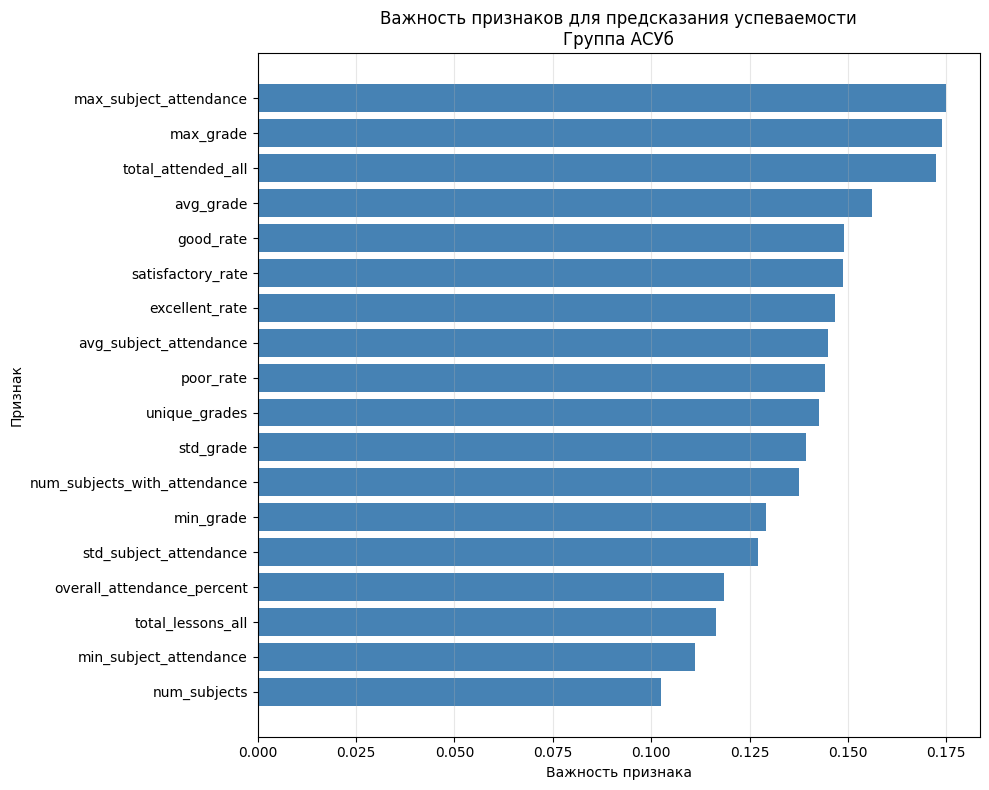


Важность признаков сохранена в 'АСУб_feature_importance.csv'


In [38]:
# ============================================================
# АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ============================================================

print("\n" + "="*60)
print("ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ ПРЕДСКАЗАНИЯ:")
print("="*60)

def analyze_feature_importance(model, feature_cols):
    """
    Анализирует важность признаков по весам первого слоя
    """
    # Получаем веса первого слоя
    weights = model.model[0].weight.data.cpu().numpy()
    importance = np.mean(np.abs(weights), axis=0)

    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=False)

    return feature_importance

importance_df = analyze_feature_importance(model, feature_cols)
print(importance_df.to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title(f'Важность признаков для предсказания успеваемости\nГруппа {TARGET_GROUP}')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Сохраняем важность признаков
importance_filename = f'{TARGET_GROUP}_feature_importance.csv'
importance_df.to_csv(importance_filename, index=False, encoding='utf-8')
print(f"\nВажность признаков сохранена в '{importance_filename}'")


ПРЕДСКАЗАНИЯ ДЛЯ СТУДЕНТОВ 1 КУРСА

РЕКОМЕНДАЦИИ ДЛЯ СТУДЕНТОВ 1 КУРСА

Топ-10 студентов с лучшими прогнозами:
  Студент 2461822: текущая оценка 4.48, прогноз 4.91 (изменение: +0.43), посещаемость: 96.9%
  Студент 2470089: текущая оценка 4.57, прогноз 4.80 (изменение: +0.23), посещаемость: 96.3%
  Студент 2469466: текущая оценка 4.51, прогноз 4.73 (изменение: +0.23), посещаемость: 94.6%
  Студент 2467807: текущая оценка 4.41, прогноз 4.64 (изменение: +0.23), посещаемость: 95.8%
  Студент 2458604: текущая оценка 4.92, прогноз 4.63 (изменение: -0.29), посещаемость: 94.7%
  Студент 2470238: текущая оценка 4.91, прогноз 4.63 (изменение: -0.29), посещаемость: 96.8%
  Студент 2469017: текущая оценка 4.68, прогноз 4.60 (изменение: -0.07), посещаемость: 96.5%
  Студент 2463583: текущая оценка 4.55, прогноз 4.51 (изменение: -0.04), посещаемость: 96.5%
  Студент 2469406: текущая оценка 4.48, прогноз 4.39 (изменение: -0.09), посещаемость: 96.5%
  Студент 2470268: текущая оценка 4.07, прогноз 4.2

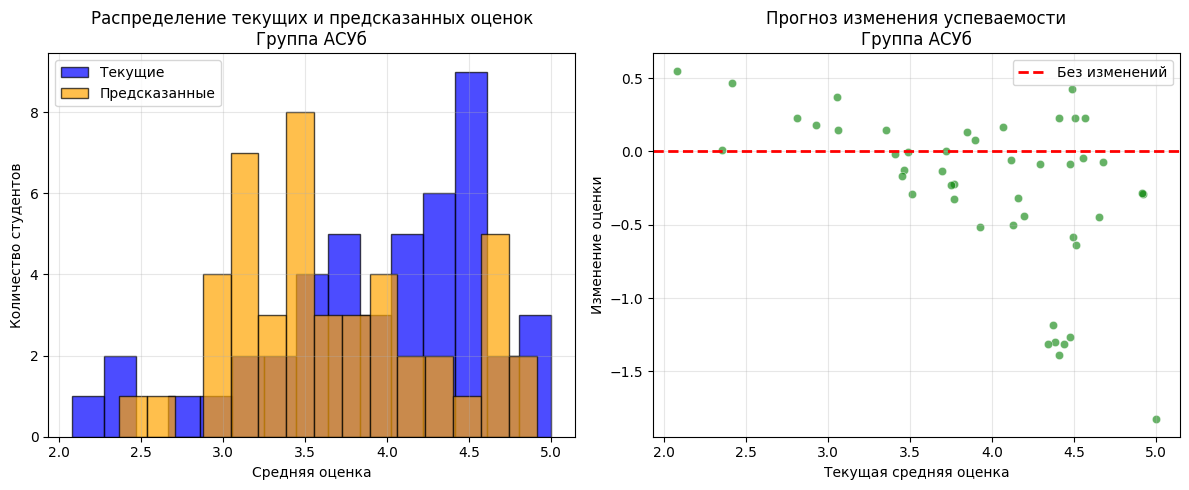

In [41]:
# ============================================================
# ПРЕДСКАЗАНИЯ ДЛЯ СТУДЕНТОВ 1 КУРСА
# ============================================================

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЯ ДЛЯ СТУДЕНТОВ 1 КУРСА")
print("="*60)

# Функция для предсказания оценок студентов 1 курса
def predict_first_course_students(model, scaler, first_course_df, feature_cols, device='cpu'):
    """
    Предсказывает успеваемость студентов 1 курса на следующем курсе
    """
    model.eval()
    results = []

    for _, student in first_course_df.iterrows():
        # Формируем признаки
        features = np.array([student[col] for col in feature_cols]).reshape(1, -1)
        features_scaled = scaler.transform(features)

        # Предсказание
        with torch.no_grad():
            features_tensor = torch.FloatTensor(features_scaled).to(device)
            predicted_grade_raw = model(features_tensor).item()

            # Ограничиваем диапазон [2.0, 5.0]
            predicted_grade = max(2.0, min(5.0, predicted_grade_raw))

        # Получаем процент посещаемости студента
        attendance_percent = student['overall_attendance_percent'] if 'overall_attendance_percent' in student.index else 0

        results.append({
            'mira_id': student['mira_id'],
            'current_avg_grade': student['avg_grade'],
            'predicted_future_grade': predicted_grade,
            'predicted_raw': predicted_grade_raw,
            'group': student['group'],
            'improvement': predicted_grade - student['avg_grade'],
            'attendance_percent': attendance_percent  # Добавляем процент посещаемости
        })

    return pd.DataFrame(results)

# Предсказываем для студентов 1 курса
if len(course1) > 0:
    predictions_df = predict_first_course_students(
        model, scaler, course1, feature_cols, device
    )

    # ============================================================
    # ВЫВОД РЕКОМЕНДАЦИЙ
    # ============================================================

    print("\n" + "="*60)
    print("РЕКОМЕНДАЦИИ ДЛЯ СТУДЕНТОВ 1 КУРСА")
    print("="*60)

    # Сортируем по прогнозу
    predictions_df = predictions_df.sort_values('predicted_future_grade', ascending=False)

    # Топ-10 студентов с лучшими прогнозами
    print("\nТоп-10 студентов с лучшими прогнозами:")
    top_students = predictions_df.head(10)
    for _, student in top_students.iterrows():
        print(f"  Студент {student['mira_id']:.0f}: текущая оценка {student['current_avg_grade']:.2f}, "
              f"прогноз {student['predicted_future_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
              f"посещаемость: {student['attendance_percent']:.1f}%")

    # Топ-10 студентов с худшими прогнозами
    print("\nТоп-10 студентов с худшими прогнозами:")
    bottom_students = predictions_df.tail(10).sort_values('predicted_future_grade', ascending=True)
    for _, student in bottom_students.iterrows():
        print(f"  Студент {student['mira_id']:.0f}: текущая оценка {student['current_avg_grade']:.2f}, "
              f"прогноз {student['predicted_future_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
              f"посещаемость: {student['attendance_percent']:.1f}%")

    # Статистика по предсказаниям
    print(f"\nСтатистика предсказаний:")
    print(f"Средняя текущая оценка: {predictions_df['current_avg_grade'].mean():.2f}")
    print(f"Средняя предсказанная оценка: {predictions_df['predicted_future_grade'].mean():.2f}")
    print(f"Среднее изменение: {predictions_df['improvement'].mean():+.2f}")
    print(f"Средняя посещаемость: {predictions_df['attendance_percent'].mean():.1f}%")

    # ============================================================
    # ВЫДЕЛЕНИЕ ГРУПП РИСКА И ПОТЕНЦИАЛА
    # ============================================================

    # Студенты с риском ухудшения успеваемости (изменение < -0.3)
    at_risk_students = predictions_df[predictions_df['improvement'] < -0.3].sort_values('improvement', ascending=True)

    print(f"\nСтуденты с риском ухудшения успеваемости ({len(at_risk_students)} чел.):")
    for _, student in at_risk_students.head(25).iterrows():  # Показываем первых 25
        print(f"  Студент {student['mira_id']:.0f}: текущая оценка {student['current_avg_grade']:.2f}, "
              f"прогноз {student['predicted_future_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
              f"посещаемость: {student['attendance_percent']:.1f}%")

    # Студенты с потенциалом улучшения (изменение > 0.3)
    improving_students = predictions_df[predictions_df['improvement'] > 0.3].sort_values('improvement', ascending=False)

    if len(improving_students) > 0:
        print(f"\nСтуденты с потенциалом улучшения ({len(improving_students)} чел.):")
        for _, student in improving_students.iterrows():
            print(f"  Студент {student['mira_id']:.0f}: текущая оценка {student['current_avg_grade']:.2f}, "
                  f"прогноз {student['predicted_future_grade']:.2f} (улучшение: {student['improvement']:+.2f}), "
                  f"посещаемость: {student['attendance_percent']:.1f}%")
    else:
        print("\nСтуденты с потенциалом улучшения: не обнаружены")

    # ============================================================
    # СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ
    # ============================================================

    predictions_filename = f'{TARGET_GROUP}_first_course_predictions.csv'
    predictions_df.to_csv(predictions_filename, index=False, encoding='utf-8')
    print(f"\nПредсказания для студентов 1 курса сохранены в '{predictions_filename}'")

    # ============================================================
    # ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
    # ============================================================

    # График распределения текущих и предсказанных оценок
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Гистограмма
    axes[0].hist(predictions_df['current_avg_grade'], bins=15, alpha=0.7,
                 label='Текущие', color='blue', edgecolor='black')
    axes[0].hist(predictions_df['predicted_future_grade'], bins=15, alpha=0.7,
                 label='Предсказанные', color='orange', edgecolor='black')
    axes[0].set_xlabel('Средняя оценка')
    axes[0].set_ylabel('Количество студентов')
    axes[0].set_title(f'Распределение текущих и предсказанных оценок\nГруппа {TARGET_GROUP}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График улучшений
    axes[1].scatter(predictions_df['current_avg_grade'], predictions_df['improvement'],
                    alpha=0.6, c='green', edgecolors='white', linewidth=0.5)
    axes[1].axhline(y=0, color='red', linestyle='--', label='Без изменений', linewidth=2)
    axes[1].set_xlabel('Текущая средняя оценка')
    axes[1].set_ylabel('Изменение оценки')
    axes[1].set_title(f'Прогноз изменения успеваемости\nГруппа {TARGET_GROUP}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print(f"\nВНИМАНИЕ: Нет студентов 1 курса в группе {TARGET_GROUP}!")
    print("Невозможно сделать предсказания для будущей успеваемости.")

In [31]:
# ============================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ (ПРЕДСКАЗАНИЕ СО 2 НА 3 КУРС)
# ============================================================

print("\nПодготовка данных для модели предсказания (2→3 курс)...")

# Разделяем студентов по курсам
course1 = features_df[features_df['student_course'] == 1]
course2 = features_df[features_df['student_course'] == 2]
course3 = features_df[features_df['student_course'] == 3]
course4 = features_df[features_df['student_course'] == 4]

print(f"Студентов 1 курса: {len(course1)}")
print(f"Студентов 2 курса: {len(course2)}")
print(f"Студентов 3 курса: {len(course3)}")
print(f"Студентов 4 курса: {len(course4)}")

# Признаки для модели
feature_cols = [
    'avg_grade', 'std_grade', 'min_grade', 'max_grade',
    'num_subjects', 'excellent_rate', 'good_rate',
    'satisfactory_rate', 'poor_rate', 'unique_grades',
    'total_lessons_all', 'total_attended_all', 'overall_attendance_percent',
    'avg_subject_attendance', 'std_subject_attendance',
    'min_subject_attendance', 'max_subject_attendance',
    'num_subjects_with_attendance'
]

# ============================================================
# ОБУЧЕНИЕ: предсказываем 3 курс по данным 2 курса
# ============================================================

print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛИ: предсказание успеваемости на 3 курсе по данным 2 курса")
print("="*60)

# Нам нужно сопоставить данные студента на 2 курсе с его же данными на 3/4 курсе
# Для этого создадим словарь с данными студентов по курсам

# Данные студентов на 2 курсе
course2_data = {}
for _, student in course2.iterrows():
    course2_data[student['mira_id']] = {
        'features': [student[col] for col in feature_cols],
        'avg_grade_2': student['avg_grade'],
        'attendance': student['overall_attendance_percent'] if 'overall_attendance_percent' in student.index else 0
    }

print(f"Студентов с данными на 2 курсе: {len(course2_data)}")

# Данные студентов на 3 и 4 курсах (их текущая успеваемость)
X = []
y = []
student_ids = []  # для отслеживания

# Для студентов 3 курса: предсказываем их успеваемость на 3 курсе по данным со 2 курса
for _, student in course3.iterrows():
    mira_id = student['mira_id']
    if mira_id in course2_data:
        features = course2_data[mira_id]['features']
        X.append(features)
        y.append(student['avg_grade'])
        student_ids.append(mira_id)
        print(f"  Найден студент {mira_id}: 2 курс → 3 курс")

# Для студентов 4 курса: тоже можем использовать (их данные со 2 курса -> успеваемость на 3 курсе)
for _, student in course4.iterrows():
    mira_id = student['mira_id']
    if mira_id in course2_data:
        features = course2_data[mira_id]['features']
        X.append(features)
        y.append(student['avg_grade'])
        student_ids.append(mira_id)
        print(f"  Найден студент {mira_id}: 2 курс → 4 курс (используем как данные для 3 курса)")

X = np.array(X)
y = np.array(y)

print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

# ============================================================
# ЕСЛИ ДАННЫХ НЕТ - ИСПОЛЬЗУЕМ АЛЬТЕРНАТИВНЫЙ ПОДХОД
# ============================================================

if len(X) == 0:
    print("\n" + "="*60)
    print("ВНИМАНИЕ: Нет студентов, у которых есть данные и на 2, и на 3/4 курсе!")
    print("Используем альтернативный подход: обучаем модель на данных 3→4 курс")
    print("="*60)

    # Альтернативный подход: предсказываем 4 курс по данным 3 курса
    course3_data = {}
    for _, student in course3.iterrows():
        course3_data[student['mira_id']] = {
            'features': [student[col] for col in feature_cols],
            'avg_grade_3': student['avg_grade']
        }

    X_alt = []
    y_alt = []

    for _, student in course4.iterrows():
        mira_id = student['mira_id']
        if mira_id in course3_data:
            features = course3_data[mira_id]['features']
            X_alt.append(features)
            y_alt.append(student['avg_grade'])
            print(f"  Найден студент {mira_id}: 3 курс → 4 курс")

    X = np.array(X_alt)
    y = np.array(y_alt)

    print(f"\nРазмерность X (альтернативный подход): {X.shape}")
    print(f"Размерность y (альтернативный подход): {y.shape}")

    if len(X) == 0:
        print("\n" + "="*60)
        print("ОШИБКА: Недостаточно данных для обучения модели!")
        print("Возможные причины:")
        print("1. Студенты отчислились/перевелись между курсами")
        print("2. В данных нет студентов, которые учились бы несколько лет подряд")
        print("3. Нужно использовать другую группу с более полными данными")
        print("="*60)
        print("\nРекомендация: используйте модель 1→2 курс, так как для нее данных достаточно.")
        print("Пропускаем обучение модели 2→3 курс.")

        # Создаем пустые переменные, чтобы избежать ошибок
        model = None
        scaler = None
        X_train = None
        y_train = None
    else:
        # Продолжаем обучение с альтернативными данными
        pass

# ============================================================
# ОБУЧЕНИЕ МОДЕЛИ (если данные есть)
# ============================================================

if len(X) > 0:
    # Нормализация
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Проверяем, хватит ли данных для train/test split
    if len(X) < 5:
        print("\nВНИМАНИЕ: Очень мало данных! Используем весь набор для обучения без валидации.")
        X_train, y_train = X_scaled, y
        X_test, y_test = X_scaled, y  # для оценки используем те же данные
        test_size_info = "данные только для обучения"
    else:
        # Разделение на train/test
        test_size = min(0.2, 1 - 2/len(X))  # адаптивный test_size
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=42
        )
        test_size_info = f"test_size={test_size:.2f}"

    print(f"Тренировочные примеры: {X_train.shape[0]}")
    print(f"Тестовые примеры: {X_test.shape[0]} ({test_size_info})")

    # Dataset класс
    class StudentDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y).unsqueeze(1)

        def __len__(self):
            return len(self.X)

        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    # Модель
    class GradeRegressor(nn.Module):
        def __init__(self, input_size):
            super(GradeRegressor, self).__init__()
            self.model = nn.Sequential(
                nn.Linear(input_size, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Linear(8, 1)
            )

        def forward(self, x):
            return self.model(x)

    # Инициализация
    input_size = X_train.shape[1]
    model = GradeRegressor(input_size)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # DataLoader
    train_dataset = StudentDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=min(16, len(X_train)), shuffle=True)

    if len(X_test) > 0 and X_test.shape[0] > 0:
        test_dataset = StudentDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=min(16, len(X_test)), shuffle=False)
    else:
        test_loader = None

    # Обучение
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    num_epochs = 200
    train_losses = []
    val_losses = []

    print("\nНачинаем обучение модели...")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation (если есть)
        if test_loader:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    predictions = model(batch_X)
                    loss = criterion(predictions, batch_y)
                    val_loss += loss.item()
            avg_val_loss = val_loss / len(test_loader)
            val_losses.append(avg_val_loss)
        else:
            avg_val_loss = None

        if (epoch + 1) % 20 == 0:
            val_msg = f", Val Loss: {avg_val_loss:.4f}" if avg_val_loss else ""
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}{val_msg}")

    # Оценка модели
    def evaluate_model(model, X_data, y_data, device='cpu'):
        model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_data).to(device)
            predictions = model(X_tensor).cpu().numpy().flatten()

        mae = mean_absolute_error(y_data, predictions)
        mse = mean_squared_error(y_data, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_data, predictions)

        return {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'predictions': predictions,
            'targets': y_data
        }

    metrics = evaluate_model(model, X_scaled, y, device)

    print("\n" + "="*60)
    print(f"МЕТРИКИ КАЧЕСТВА МОДЕЛИ ДЛЯ ГРУППЫ {TARGET_GROUP} (2→3 курс):")
    print("="*60)
    print(f"MAE: {metrics['MAE']:.3f}")
    print(f"RMSE: {metrics['RMSE']:.3f}")
    print(f"R²: {metrics['R2']:.3f}")

    # ============================================================
    # ПРЕДСКАЗАНИЯ ДЛЯ СТУДЕНТОВ 2 КУРСА (если есть)
    # ============================================================

    if len(course2) > 0 and model is not None:
        print("\n" + "="*60)
        print("ПРЕДСКАЗАНИЯ ДЛЯ СТУДЕНТОВ 2 КУРСА")
        print("="*60)

        def predict_course_students(model, scaler, target_course_df, feature_cols, device='cpu'):
            model.eval()
            results = []

            for _, student in target_course_df.iterrows():
                features = np.array([student[col] for col in feature_cols]).reshape(1, -1)
                features_scaled = scaler.transform(features)

                with torch.no_grad():
                    features_tensor = torch.FloatTensor(features_scaled).to(device)
                    predicted_grade_raw = model(features_tensor).item()
                    predicted_grade = max(2.0, min(5.0, predicted_grade_raw))

                results.append({
                    'mira_id': student['mira_id'],
                    'current_avg_grade': student['avg_grade'],
                    'predicted_next_grade': predicted_grade,
                    'group': student['group'],
                    'improvement': predicted_grade - student['avg_grade'],
                    'attendance_percent': student['overall_attendance_percent'] if 'overall_attendance_percent' in student.index else 0
                })

            return pd.DataFrame(results)

        predictions_df = predict_course_students(model, scaler, course2, feature_cols, device)

        print("\nТоп-10 студентов с лучшими прогнозами на 3 курс:")
        top_students = predictions_df.nlargest(10, 'predicted_next_grade')
        for _, student in top_students.iterrows():
            print(f"  Студент {student['mira_id']:.0f}: текущая оценка (2 курс) {student['current_avg_grade']:.2f}, "
                  f"прогноз на 3 курс {student['predicted_next_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
                  f"посещаемость: {student['attendance_percent']:.1f}%")

        print("\nТоп-10 студентов с худшими прогнозами на 3 курс:")
        bottom_students = predictions_df.nsmallest(10, 'predicted_next_grade')
        for _, student in bottom_students.iterrows():
            print(f"  Студент {student['mira_id']:.0f}: текущая оценка (2 курс) {student['current_avg_grade']:.2f}, "
                  f"прогноз на 3 курс {student['predicted_next_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
                  f"посещаемость: {student['attendance_percent']:.1f}%")

        # Статистика по предсказаниям
        print(f"\nСтатистика предсказаний:")
        print(f"Средняя текущая оценка (2 курс): {predictions_df['current_avg_grade'].mean():.2f}")
        print(f"Средняя предсказанная оценка (3 курс): {predictions_df['predicted_next_grade'].mean():.2f}")
        print(f"Среднее изменение: {predictions_df['improvement'].mean():+.2f}")
        print(f"Средняя посещаемость: {predictions_df['attendance_percent'].mean():.1f}%")

        # Студенты с риском ухудшения
        at_risk = predictions_df[predictions_df['improvement'] < -0.3].sort_values('improvement')
        if len(at_risk) > 0:
            print(f"\nСтуденты с риском ухудшения успеваемости (2→3 курс) ({len(at_risk)} чел.):")
            for _, student in at_risk.head(25).iterrows():
                print(f"  Студент {student['mira_id']:.0f}: текущая оценка {student['current_avg_grade']:.2f}, "
                      f"прогноз на 3 курс {student['predicted_next_grade']:.2f} (изменение: {student['improvement']:+.2f}), "
                      f"посещаемость: {student['attendance_percent']:.1f}%")

        # Сохраняем предсказания
        predictions_filename = f'{TARGET_GROUP}_course2_to_course3_predictions.csv'
        predictions_df.to_csv(predictions_filename, index=False, encoding='utf-8')
        print(f"\nПредсказания для студентов 2 курса сохранены в '{predictions_filename}'")

    else:
        print("\nНет студентов 2 курса для предсказаний или модель не обучена.")

else:
    print("\n" + "="*60)
    print("НЕВОЗМОЖНО ОБУЧИТЬ МОДЕЛЬ: нет данных для обучения.")
    print("Рекомендуется использовать модель 1→2 курс.")
    print("="*60)


Подготовка данных для модели предсказания (2→3 курс)...
Студентов 1 курса: 46
Студентов 2 курса: 43
Студентов 3 курса: 39
Студентов 4 курса: 4

ОБУЧЕНИЕ МОДЕЛИ: предсказание успеваемости на 3 курсе по данным 2 курса
Студентов с данными на 2 курсе: 43

Размерность X: (0,)
Размерность y: (0,)

ВНИМАНИЕ: Нет студентов, у которых есть данные и на 2, и на 3/4 курсе!
Используем альтернативный подход: обучаем модель на данных 3→4 курс

Размерность X (альтернативный подход): (0,)
Размерность y (альтернативный подход): (0,)

ОШИБКА: Недостаточно данных для обучения модели!
Возможные причины:
1. Студенты отчислились/перевелись между курсами
2. В данных нет студентов, которые учились бы несколько лет подряд
3. Нужно использовать другую группу с более полными данными

Рекомендация: используйте модель 1→2 курс, так как для нее данных достаточно.
Пропускаем обучение модели 2→3 курс.

НЕВОЗМОЖНО ОБУЧИТЬ МОДЕЛЬ: нет данных для обучения.
Рекомендуется использовать модель 1→2 курс.
